In [ ]:
# ============================================================
# Tutorial: Logistic Regression vs GDA vs Naive Bayes
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.metrics import accuracy_score, confusion_matrix

# Generate a simple binary classification dataset
X, y = make_classification(
    n_samples=300, n_features=2, n_redundant=0, n_clusters_per_class=1,
    class_sep=1.2, random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)


In [ ]:
# ============================================================
# Train all models and compare accuracy + time
# ============================================================

models = {
    "Logistic Regression": LogisticRegression(),
    "GDA": QuadraticDiscriminantAnalysis(store_covariance=True),
    "Naive Bayes": GaussianNB()
}

for name, model in models.items():
    start_time = time.time()
    model.fit(X_train, y_train)
    end_time = time.time()
    preds = model.predict(X_test)
    print(f"{name} Accuracy: {accuracy_score(y_test, preds):.3f}")
    print("Confusion Matrix:\n", confusion_matrix(y_test, preds))
    print(f"Training Time: {(end_time - start_time)*1000:.2f} ms\n")


Logistic Regression Accuracy: 0.978
Confusion Matrix:
 [[44  1]
 [ 1 44]]
Training Time: 68.63 ms

GDA Accuracy: 0.989
Confusion Matrix:
 [[45  0]
 [ 1 44]]
Training Time: 26.15 ms

Naive Bayes Accuracy: 0.978
Confusion Matrix:
 [[44  1]
 [ 1 44]]
Training Time: 3.65 ms



In [ ]:
# ------------------------------------------------------------
# Covariance Matrix Comparison
# ------------------------------------------------------------
print("\n==== COVARIANCE STRUCTURE COMPARISON ====\n")

# Logistic Regression: no covariance matrix modeled
print("Logistic Regression: Does not estimate covariance explicitly.\n")

# GDA: full covariance matrix per class
gda = models["GDA"]
for i, cov in enumerate(gda.covariance_):
    print(f"GDA Covariance Matrix for Class {i}:\n{cov}\n")

# Naive Bayes: diagonal covariance (variances only)
nb = models["Naive Bayes"]
for i, var in enumerate(nb.var_):
    print(f"Naive Bayes Variance for Feature {i} (per class stored separately):")
print("Class Means:\n", nb.theta_)
print("Class Variances:\n", nb.var_, "\n")


==== COVARIANCE STRUCTURE COMPARISON ====

Logistic Regression: Does not estimate covariance explicitly.

GDA Covariance Matrix for Class 0:
[[0.07360597 0.1399887 ]
 [0.1399887  0.32950345]]

GDA Covariance Matrix for Class 1:
[[ 0.71526657 -0.34628622]
 [-0.34628622  0.55596371]]

Naive Bayes Variance for Feature 0 (per class stored separately):
Naive Bayes Variance for Feature 1 (per class stored separately):
Class Means:
 [[ 1.19214585 -1.22342045]
 [ 1.12964663  1.18892388]]
Class Variances:
 [[0.07290497 0.32636533]
 [0.70845451 0.55066882]] 



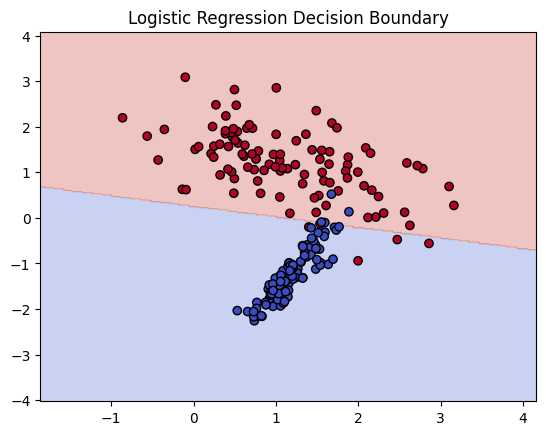

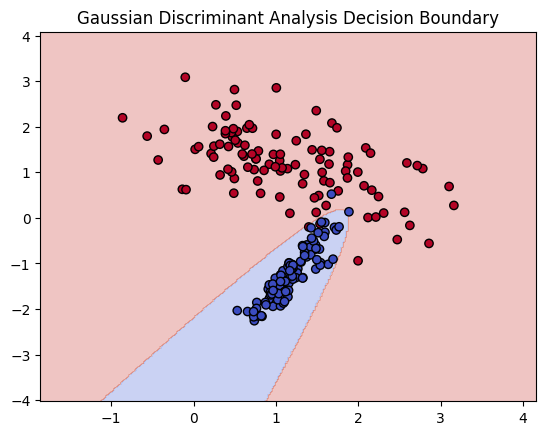

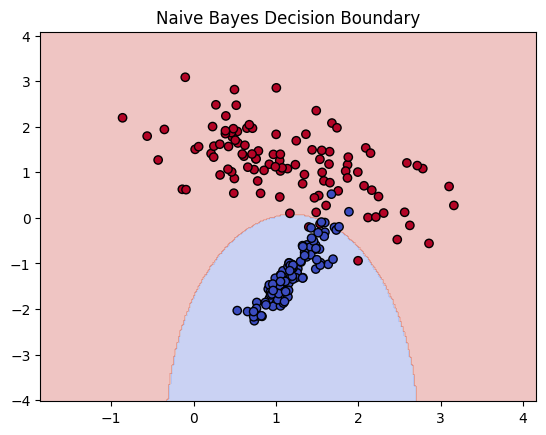

In [ ]:
# ============================================================
# Function to visualize decision boundaries
# ============================================================

def plot_boundary(model, title):
    x_min, x_max = X[:, 0].min()-1, X[:, 0].max()+1
    y_min, y_max = X[:, 1].min()-1, X[:, 1].max()+1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
    plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, edgecolor='k', cmap=plt.cm.coolwarm)
    plt.title(title)
    plt.show()

# Visualize all three decision boundaries
plot_boundary(models["Logistic Regression"], "Logistic Regression Decision Boundary")
plot_boundary(models["GDA"], "Gaussian Discriminant Analysis Decision Boundary")
plot_boundary(models["Naive Bayes"], "Naive Bayes Decision Boundary")


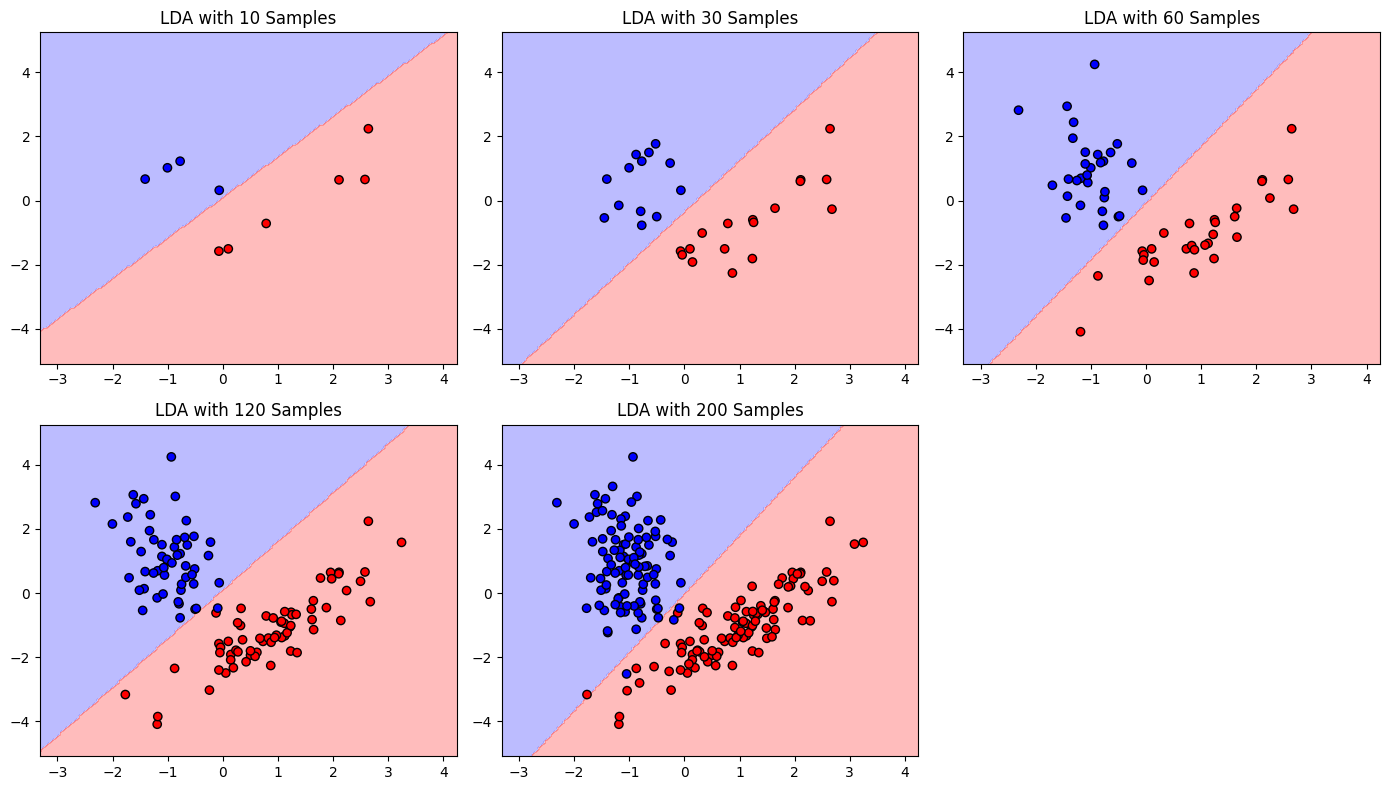

In [ ]:
# ============================================================
# Linear Discriminant Analysis (LDA) Boundary Evolution
# ============================================================

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

X_lda, y_lda = make_classification(
    n_samples=200, n_features=2, n_redundant=0, n_clusters_per_class=1,
    class_sep=1.0, random_state=7
)

# Shuffle data for incremental visualization
indices = np.random.permutation(len(X_lda))
X_lda, y_lda = X_lda[indices], y_lda[indices]

# Define function to plot LDA decision boundary evolution
def plot_lda_evolution(X, y, steps=[10, 30, 60, 120, 200]):
    plt.figure(figsize=(14, 8))
    for i, n in enumerate(steps, 1):
        lda = LDA()
        lda.fit(X[:n], y[:n])

        # Create mesh grid for decision boundary
        x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
        y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
        xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                             np.linspace(y_min, y_max, 200))
        Z = lda.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

        plt.subplot(2, 3, i)
        plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.bwr)
        plt.scatter(X[:n, 0], X[:n, 1], c=y[:n], edgecolor='k', cmap=plt.cm.bwr)
        plt.title(f"LDA with {n} Samples")

    plt.tight_layout()
    plt.show()

plot_lda_evolution(X_lda, y_lda)


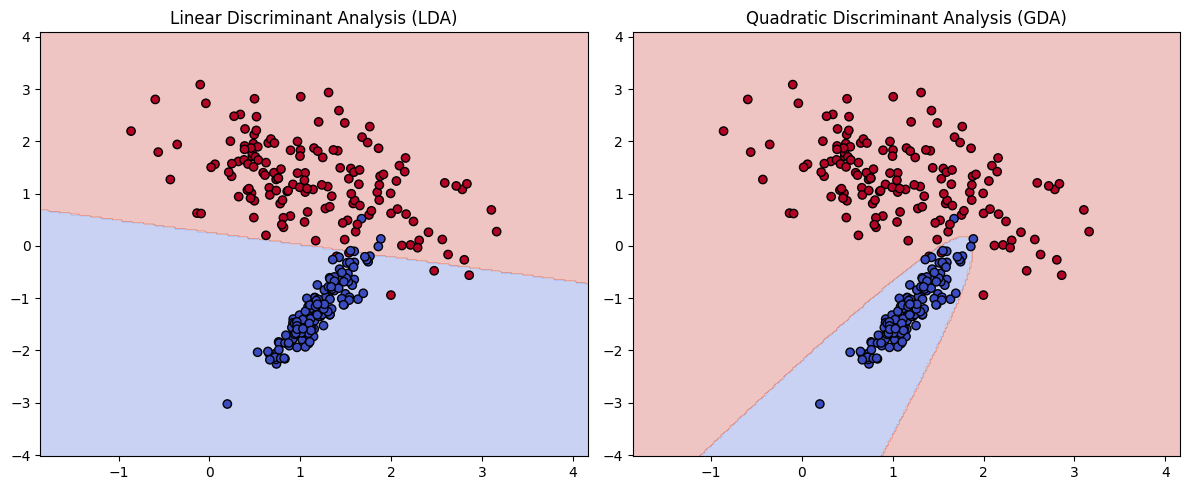

LDA Accuracy: 0.978
GDA Accuracy: 0.989


In [ ]:
# ============================================================
# LDA vs GDA Comparison on Same Dataset
# ============================================================

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Train LDA (Linear Discriminant Analysis) and GDA (Quadratic Discriminant Analysis)
lda_same = LinearDiscriminantAnalysis()
gda_same = QuadraticDiscriminantAnalysis(store_covariance=True)

lda_same.fit(X_train, y_train)
gda_same.fit(X_train, y_train)

def plot_decision_boundary(ax, model, X, y, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
    ax.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k', cmap=plt.cm.coolwarm)
    ax.set_title(title)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_decision_boundary(axes[0], lda_same, X, y, "Linear Discriminant Analysis (LDA)")
plot_decision_boundary(axes[1], gda_same, X, y, "Quadratic Discriminant Analysis (GDA)")
plt.tight_layout()
plt.show()

# Evaluate accuracies
lda_acc = accuracy_score(y_test, lda_same.predict(X_test))
gda_acc = accuracy_score(y_test, gda_same.predict(X_test))
print(f"LDA Accuracy: {lda_acc:.3f}")
print(f"GDA Accuracy: {gda_acc:.3f}")


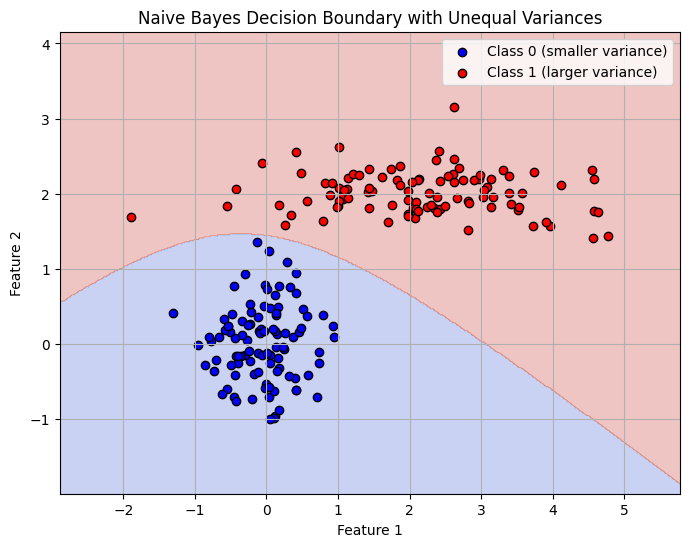

Class Means:
 [[-0.05778213  0.01701116]
 [ 2.15389847  2.01304629]]
Class Variances:
 [[0.1814849  0.24693531]
 [1.54069326 0.07785839]]


In [ ]:
# ============================================================
# Visualization: Why Naive Bayes can produce curved boundaries
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB

# ------------------------------------------------------------
# Generate two classes with different variances
# ------------------------------------------------------------
np.random.seed(42)
# Class 0: narrow Gaussian (small variance)
X0 = np.random.normal(loc=[0, 0], scale=[0.5, 0.5], size=(100, 2))
# Class 1: wider Gaussian (large variance)
X1 = np.random.normal(loc=[2, 2], scale=[1.2, 0.3], size=(100, 2))

X = np.vstack([X0, X1])
y = np.hstack([np.zeros(100), np.ones(100)])

# ------------------------------------------------------------
# Fit Gaussian Naive Bayes
# ------------------------------------------------------------
nb = GaussianNB()
nb.fit(X, y)

# ------------------------------------------------------------
# Create mesh grid to visualize decision boundary
# ------------------------------------------------------------
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400),
                     np.linspace(y_min, y_max, 400))
Z = nb.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

# ------------------------------------------------------------
# Plot boundary and data
# ------------------------------------------------------------
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
plt.scatter(X0[:, 0], X0[:, 1], color='blue', label='Class 0 (smaller variance)', edgecolor='k')
plt.scatter(X1[:, 0], X1[:, 1], color='red', label='Class 1 (larger variance)', edgecolor='k')
plt.title("Naive Bayes Decision Boundary with Unequal Variances")
plt.legend()
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.show()

# ------------------------------------------------------------
# Print class-wise means and variances
# ------------------------------------------------------------
print("Class Means:\n", nb.theta_)
print("Class Variances:\n", nb.var_)
